# Loading Dataset



## CSV Understanding

MolLogP	MolWt	NumRotatableBonds	AromaticProportion	logS
2.5954000000000006	167.85	0.0	0.0	-2.18
2.376500000000001	133.405	0.0	0.0	-2.0
2.5938	167.85	1.0	0.0	-1.74
2.0289	133.405	1.0	0.0	-1.48
2.9189	187.37500000000003	1.0	0.0	-3.04
1.81	98.96000000000001	0.0	0.0	-1.29
1.9352	96.94399999999999	0.0	0.0	-1.64

| MolLogP | MolWt   | NumRotatableBonds | AromaticProportion | logS  |
|----------|----------|-------------------|---------------------|-------|
| 2.5954   | 167.85  | 0.0               | 0.0                 | -2.18 |
| 2.3765   | 133.405 | 0.0               | 0.0                 | -2.00 |
| 2.5938   | 167.85  | 1.0               | 0.0                 | -1.74 |
| 2.0289   | 133.405 | 1.0               | 0.0                 | -1.48 |
| 2.9189   | 187.375 | 1.0               | 0.0                 | -3.04 |
| 1.8100   | 98.96   | 0.0               | 0.0                 | -1.29 |
| 1.9352   | 96.944  | 0.0               | 0.0                 | -1.64 |



Headers:

`MolLogP	MolWt	NumRotatableBonds	AromaticProportion	logS`

Now this guy likes to put the output variable/dependent variable **(y)** at the end (we're gonna be predicting this)

Y = f(x)

everyother one is serveral X's, Multivariate analysis,

logS is the Fx(...) here

In [2]:
import pandas as pd
'''Using Pandas as our datahandling library'''

'''Load in the CSV
 DF Means Dataframe

'''

df = pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv")

df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


# Data prep


### Data Separation into X and Y

so far we're gonna extract the Y from the dataset

Now we want to create an X that only has the X variables (no Y)


In [3]:
y = df['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [4]:
x = df.drop('logS',axis=1)

'''
axis = 1 ---> Remove the Column
axis = 0 ---> Remove the ROW (could be used to get rid of header colums)
'''

x

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


### Split it into Training and Testing

we'll use sklearn package for thisss

PARAMETERS:

**test_size**

float or int, default=None. If float, should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split

**random_state**

is a parameter in train_test_split that controls the random number generator used to shuffle the data before splitting it. In other words, it ensures that the same randomization is used each time you run the code, resulting in the same splits of the data.

Why?

Typically we use 80% of our dataset to train our models to build from a trainingSet. we'd use that to predict our testing set


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=100)


In [6]:
X_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [7]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
1114,1.76210,478.513,4.0,0.000000
427,6.32820,276.338,0.0,1.000000
711,0.04430,218.205,5.0,0.000000
4,2.91890,187.375,1.0,0.000000


In [8]:
y_train

,logS
107,-4.440
378,-1.250
529,-1.655
546,-1.886
320,-0.740
...,...
802,-2.925
53,-2.680
350,-7.020
79,-4.800


In [9]:
y_test

,logS
822,-3.380
118,-8.010
347,-2.160
1123,-1.170
924,-0.730
...,...
1114,-4.130
427,-9.018
711,-0.600
4,-3.040


# Building the Model

NOTE: WE'RE USING REGRESSIVE MODELS, if Y is quantitative, we'd use a regressive models, if it's categorical, we'd use classification


## Linear Regression

### Training the model

In [10]:
from sklearn.linear_model import LinearRegression

# Using a LinearRegression model here

# LR = Linear Regression

lr = LinearRegression() # Empty LinearRegression model

lr.fit(X_train, y_train) # Train the lr on these dataset

# Now our model is trained

LinearRegression()

### Applying the model

In [11]:
y_lr_train_pred = lr.predict(X_train)

# Simply getting a recall done here, making the same model predict the Y train data from the same X train data that was used to train it, doing this to measure performance later on

In [12]:
y_lr_test_pred = lr.predict(X_test)

# this is the new prediction on the 20% that the model hasn't seen

In [13]:
y_lr_train_pred

# it's all a single column, it's aligned into 4 because of layout, not that there's 4 columns

array([-2.83668969,  0.84208401, -0.50930302, -0.13058053, -1.6269208 ,
       -2.86103037, -2.32208333, -4.16684323, -5.04235077, -2.29737009,
       -3.15082845, -4.33037208, -1.43700682, -2.59060064, -7.09025955,
       -2.32734557, -4.19073421, -2.63904005, -3.58104074, -3.75929058,
       -2.5501665 , -3.26968347, -2.78911367, -2.69251051, -0.77437547,
       -6.61955792, -2.99084623, -2.36975061, -7.18167736, -1.52816491,
       -4.81736265, -0.86996608, -7.09025955, -1.87404275, -2.58013247,
       -4.80953284, -4.17454084, -1.95444152, -3.50503339, -2.7411418 ,
       -1.87131835, -2.45270806, -3.07252433, -1.48988982, -3.98778754,
       -1.35216679, -0.16932277, -6.05237002, -3.29550658,  0.30513174,
       -3.25501463, -5.31993586, -0.4733928 , -4.79180882, -5.82486323,
       -2.70343539, -3.70838271, -2.4987341 , -2.12301018, -3.11393974,
       -2.79842053, -1.38274662, -4.3267103 , -3.57778946, -3.42356884,
       -9.15826626, -6.52588866, -1.75832085, -4.97842312, -1.59

In [14]:
y_lr_test_pred

array([-3.05722870e+00, -7.77785827e+00, -2.55016650e+00, -2.01523582e+00,
       -2.06375990e+00, -9.99672215e-01, -5.94603364e-01, -5.53626003e-01,
       -5.72200956e+00, -3.94006681e+00, -3.95496755e+00, -2.29737009e+00,
       -1.48980354e+00, -1.48988982e+00, -4.64510806e+00, -1.90396018e+00,
       -1.51566313e+00, -3.16424605e+00, -3.70863920e+00, -5.58105660e+00,
       -3.25038467e+00, -5.04235077e+00, -5.69194881e+00, -2.14339849e+00,
       -4.35689341e+00, -5.03964756e+00, -3.10383618e+00, -4.40286964e+00,
       -4.21276272e+00,  5.56508349e-01, -1.45537678e+00, -4.41027396e+00,
       -2.59668773e+00, -1.53336276e+00, -5.55749874e-01, -1.67111795e+00,
       -2.78163675e+00, -3.15395565e+00, -5.27083361e+00, -1.75321446e+00,
       -1.53350725e+00, -2.01255666e+00, -6.57559167e+00, -7.89433046e+00,
       -5.76437127e+00, -4.16422068e+00, -3.43694663e+00,  1.43834212e+00,
       -1.12679105e-02, -2.34521849e+00, -1.86480046e+00, -5.03964756e+00,
        8.55886378e-01, -

### Performance evaluation

Looking to see if they follow the same trend line. if there's high dispersion (it won't be that good, tho else good)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train,y_lr_train_pred) # Just finding a statistic between the two
lr_train_r2 = r2_score(y_train,y_lr_train_pred) # Just finding a statistic between the two

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred) # Just finding a statistic between the two

lr_test_r2 = r2_score(y_test,y_lr_test_pred) # Just finding a statistic between the two

In [16]:
print(f'lr_train_mse: {lr_train_mse}')
print(f'lr_train_r2: {lr_train_r2}')
print(f'lr_test_mse: {lr_test_mse}')
print(f'lr_test_r2: {lr_test_r2}')



lr_train_mse: 1.0075362951093687
lr_train_r2: 0.7645051774663391
lr_test_mse: 1.0206953660861033
lr_test_r2: 0.7891616188563282


## Random Forest

### Training the model

In [17]:
from sklearn.ensemble import RandomForestRegressor


# Using a RandomForestRegressor model here

# rf = Random Forest

rf = RandomForestRegressor(max_depth=2, random_state=100) # Empty RandomForestRegressor model

# max_depth: the maximum depth of each decision tree in the forest. Setting a higher value for max_depth can lead to overfitting while setting it too low can lead to underfitting.


rf.fit(X_train, y_train) # Train the fr on these dataset

# Now our model is trained

RandomForestRegressor(max_depth=2, random_state=100)

### Applying the model

In [18]:
y_rf_train_pred = rf.predict(X_train)

# Simply getting a recall done here, making the same model predict the Y train data from the same X train data that was used to train it, doing this to measure performance later on

In [19]:
y_rf_test_pred = rf.predict(X_test)

# this is the new prediction on the 20% that the model hasn't seen

In [20]:
y_rf_train_pred

# it's all a single column, it's aligned into 4 because of layout, not that there's 4 columns

array([-4.44388581, -1.40132433, -1.41481453, -1.41481453, -1.44411435,
       -2.67492782, -2.50755276, -3.95611327, -4.62529592, -2.27343298,
       -2.69241199, -4.5150244 , -1.41481453, -2.67492782, -7.14501987,
       -2.30422396, -4.0676017 , -3.36086239, -2.53282364, -4.5150244 ,
       -2.47178242, -4.0676017 , -2.66143763, -1.42912192, -1.2164651 ,
       -7.14501987, -2.67492782, -2.47178242, -7.14501987, -1.2164651 ,
       -4.5150244 , -1.2164651 , -7.14501987, -1.41481453, -1.64246378,
       -4.5150244 , -4.5150244 , -1.41481453, -2.71012897, -1.64246378,
       -2.42959807, -2.89446137, -2.47178242, -1.24495146, -2.69241199,
       -1.2164651 , -1.2164651 , -4.65157679, -2.6279475 , -1.2164651 ,
       -1.79134844, -4.5150244 , -1.2164651 , -4.44388581, -4.62529592,
       -4.0676017 , -4.5150244 , -2.66143763, -1.41481453, -4.0676017 ,
       -2.67492782, -1.40132433, -3.32568382, -2.51725697, -4.44388581,
       -7.14501987, -7.14501987, -1.44411435, -4.5150244 , -1.42

In [21]:
y_rf_test_pred

array([-3.97313718, -7.14501987, -2.47178242, -2.40196468, -1.44411435,
       -1.40132433, -1.2164651 , -1.41481453, -7.14501987, -4.5150244 ,
       -4.5150244 , -2.27343298, -1.83979246, -1.24495146, -4.5150244 ,
       -1.40132433, -1.24495146, -2.67492782, -2.67492782, -4.65157679,
       -3.00915981, -4.62529592, -7.12312525, -2.47657839, -4.5150244 ,
       -4.5150244 , -4.5150244 , -4.5150244 , -4.44388581, -1.2164651 ,
       -1.41481453, -2.67492782, -2.67492782, -1.42961706, -1.40132433,
       -2.27343298, -2.0381419 , -2.67492782, -4.5150244 , -1.38740573,
       -1.2164651 , -1.61447629, -7.14501987, -7.14501987, -7.12312525,
       -4.42408609, -2.0381419 , -1.41481453, -1.41481453, -2.50541484,
       -1.83979246, -4.5150244 , -1.2164651 , -2.6279475 , -4.62529592,
       -1.42912192, -7.14501987, -1.2164651 , -1.41481453, -4.62529592,
       -1.62796649, -2.69241199, -2.67492782, -2.66143763, -1.2164651 ,
       -1.23077249, -2.67492782, -4.00999869, -1.41481453, -4.21

### Performance evaluation

Looking to see if they follow the same trend line. if there's high dispersion (it won't be that good, tho else good)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train,y_rf_train_pred) # Just finding a statistic between the two
rf_train_r2 = r2_score(y_train,y_rf_train_pred) # Just finding a statistic between the two

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred) # Just finding a statistic between the two

rf_test_r2 = r2_score(y_test,y_rf_test_pred) # Just finding a statistic between the two

In [23]:
print(f'rf_train_mse: {rf_train_mse}')
print(f'rf_train_r2: {rf_train_r2}')
print(f'rf_test_mse: {rf_test_mse}')
print(f'rf_test_r2: {rf_test_r2}')



rf_train_mse: 1.028227802112806
rf_train_r2: 0.7596688824431413
rf_test_mse: 1.407688264904896
rf_test_r2: 0.7092230211002489


# Model Comparison

In [24]:
Lr_Tabulated = pd.DataFrame(['Linear Regression', lr_train_mse,lr_train_r2, lr_test_mse,lr_test_r2]).transpose()
Lr_Tabulated.columns =['Model','Train MSE','Train R2', 'Test MSE', 'Test R2']
Lr_Tabulated

,Model,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


In [25]:
Rf_Tabulated = pd.DataFrame(['Random Forest', rf_train_mse,rf_train_r2, rf_test_mse,rf_test_r2]).transpose()
Rf_Tabulated.columns =['Model','Train MSE','Train R2', 'Test MSE', 'Test R2']
Rf_Tabulated

,Model,Train MSE,Train R2,Test MSE,Test R2
0,Random Forest,1.028228,0.759669,1.407688,0.709223


In [26]:
df_models = pd.concat([Lr_Tabulated,Rf_Tabulated], axis=0).reset_index(drop=True)

# Combine them in a rowwise manner

df_models

,Model,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
1,Random Forest,1.028228,0.759669,1.407688,0.709223


# Data Visualisation

Text(0.5, 0, 'Experimental LogS')

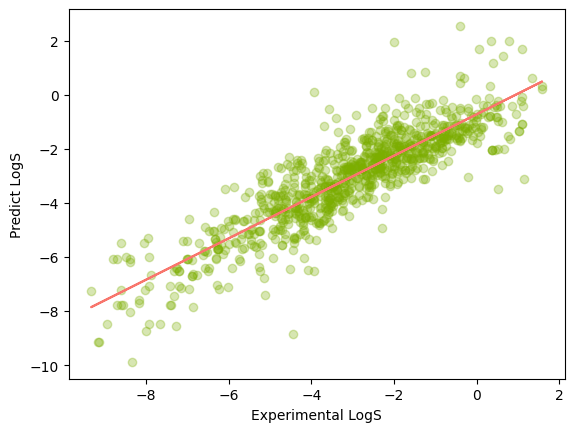

In [30]:
import matplotlib.pyplot as plt
import numpy as np


plt.scatter(x=y_train,y=y_lr_train_pred, c='#7CAE00',alpha=0.3) # u can add another atribute Alpha to add colouring stuff

z = np.polyfit(y_train,y_lr_train_pred,1)
p = np.poly1d(z)


plt.plot(y_train, p(y_train),'#F8766D')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')

Text(0.5, 0, 'Experimental LogS')

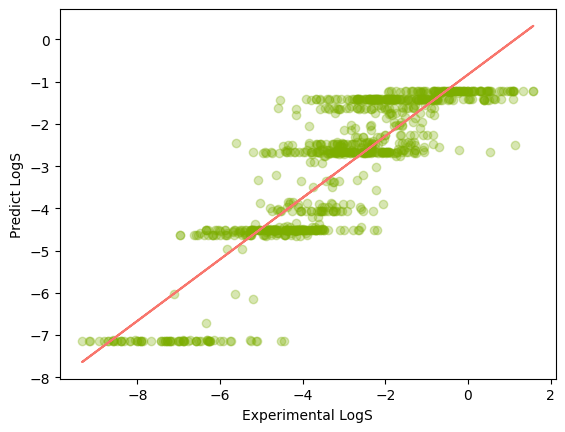

In [31]:
plt.scatter(x=y_train,y=y_rf_train_pred, c='#7CAE00',alpha=0.3) # u can add another atribute Alpha to add colouring stuff

z = np.polyfit(y_train,y_rf_train_pred,1)
p = np.poly1d(z)


plt.plot(y_train, p(y_train),'#F8766D')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')